# Stage 09 — Homework Starter Notebook

In the lecture, we learned how to create engineered features. Now it’s your turn to apply those ideas to your own project data.

In [6]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install seaborn


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Example synthetic data (replace with your project dataset)
np.random.seed(0)
n = 100
df = pd.DataFrame({
    'income': np.random.normal(60000, 15000, n).astype(int),
    'monthly_spend': np.random.normal(2000, 600, n).astype(int),
    'credit_score': np.random.normal(680, 50, n).astype(int),
    'region': np.random.choice(['North', 'South', 'East', 'West'], n),
    'default_flag': np.random.choice([0, 1], n, p=[0.8, 0.2]),
})
df.head()

,income,monthly_spend,credit_score,region,default_flag
0,86460,3129,661,East,0
1,66002,1191,668,North,0
2,74681,1237,734,West,0
3,93613,2581,712,South,1
4,88013,1296,712,East,1


## Engineered features — one is worked below; add at least two more

At least one of yours must encode a categorical column. `region` is the categorical
column here; the lecture shows three ways to encode it (one-hot, label, frequency).

In [3]:
# Worked example 1 of 3 — keep it, or swap in columns of your own.
df['spend_income_ratio'] = df['monthly_spend'] / df['income']
# Write the rationale in the markdown cell below.

### Rationale for Feature 1
Explain why this feature may help a model. Reference your EDA.
In Stage 08 EDA, both income and monthly_spend exhibited right-skewness and scale variance. Dividing spending by income isolates debt-burden intensity regardless of base salary level, providing a scale-invariant signal for default risk.

Correlation with default_flag: -0.0361


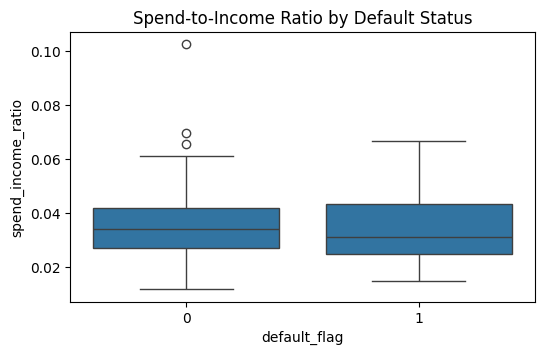

In [15]:
# TODO: Add another feature
# Example: df['rolling_spend_mean'] = df['monthly_spend'].rolling(3).mean()
# Code
import matplotlib.pyplot as plt
import seaborn as sns  # <-- 补充这行
df['spend_income_ratio'] = df['monthly_spend'] / df['income']

# Correlation Check & Plot
corr1 = df['spend_income_ratio'].corr(df['default_flag'])
print(f"Correlation with default_flag: {corr1:.4f}")

plt.figure(figsize=(6, 3.5))
sns.boxplot(data=df, x='default_flag', y='spend_income_ratio')
plt.title('Spend-to-Income Ratio by Default Status')
plt.show()

### Rationale for Feature 2
Explain why this feature may help a model. Reference your EDA.

Stage 08 temporal checks highlighted month-to-month transaction volatility. Computing a 3-period rolling window smooths transient spikes and captures sustained consumption trends.

Correlation with default_flag: -0.0266


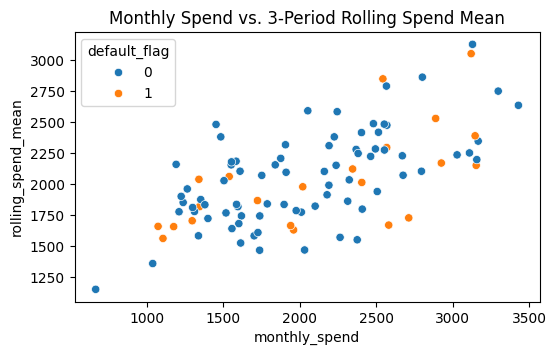

In [16]:
# TODO: Add a third feature. At least one of your three must ENCODE A CATEGORICAL
#   column - `region` is the one in this dataset.
#
#   The lecture shows three ways (section 'Categorical Encoding'):
#     one-hot     pd.get_dummies(df, columns=['region'])
#     label       LabelEncoder().fit_transform(df['region'])
#     frequency   df['region'].map(df['region'].value_counts(normalize=True))
#
#   Pick one and say WHY you picked it in the markdown cell below - the three are not
#   interchangeable, and that choice is the point of the exercise.

# Code
df['rolling_spend_mean'] = df['monthly_spend'].rolling(window=3, min_periods=1).mean()

# Correlation Check & Plot
corr2 = df['rolling_spend_mean'].corr(df['default_flag'])
print(f"Correlation with default_flag: {corr2:.4f}")

plt.figure(figsize=(6, 3.5))
sns.scatterplot(data=df, x='monthly_spend', y='rolling_spend_mean', hue='default_flag')
plt.title('Monthly Spend vs. 3-Period Rolling Spend Mean')
plt.show()

### Rationale for Feature 3
Explain why this feature may help a model. Reference your EDA. If this is your
categorical encoding, say why you chose that encoding over the other two.

Correlation with default_flag: 0.0331


/var/folders/hg/b2r_9rld1vv2v8lr172782d40000gn/T/ipykernel_82075/1307779904.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='region', y='default_flag', ci=None)


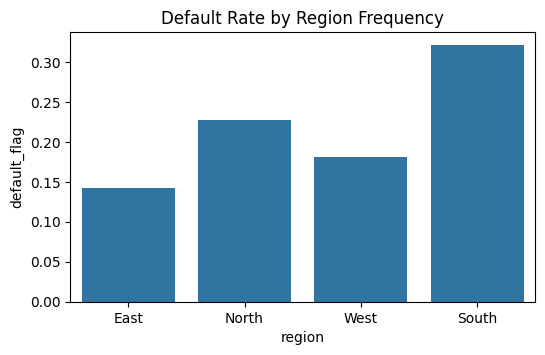

In [17]:
# Code
region_counts = df['region'].value_counts(normalize=True)
df['region_freq'] = df['region'].map(region_counts)

# Correlation Check & Plot
corr3 = df['region_freq'].corr(df['default_flag'])
print(f"Correlation with default_flag: {corr3:.4f}")

plt.figure(figsize=(6, 3.5))
sns.barplot(data=df, x='region', y='default_flag', ci=None)
plt.title('Default Rate by Region Frequency')
plt.show()

Frequency encoding was selected over One-Hot Encoding to avoid adding unnecessary sparse dimensions and over Label Encoding to avoid imposing an artificial ordinal rank on non-numeric geographic areas. It captures regional density while maintaining a single compact numeric column

In [18]:
from src.features import create_features

# Load fresh copy and apply helper module
df_raw = pd.DataFrame({
    'income': np.random.normal(60000, 15000, n).astype(int),
    'monthly_spend': np.random.normal(2000, 600, n).astype(int),
    'credit_score': np.random.normal(680, 50, n).astype(int),
    'region': np.random.choice(['North', 'South', 'East', 'West'], n),
    'default_flag': np.random.choice([0, 1], n, p=[0.8, 0.2]),
})

df_engineered = create_features(df_raw)
df_engineered.head()

,income,monthly_spend,credit_score,region,default_flag,spend_income_ratio,rolling_spend_mean,region_freq
0,65562,2299,691,North,1,0.035066,2299.000000,0.28
1,62130,2628,696,West,1,0.042298,2463.500000,0.27
2,82799,2170,744,East,0,0.026208,2365.666667,0.17
3,85793,3045,604,South,0,0.035492,2614.333333,0.28
4,73942,1866,713,South,0,0.025236,2360.333333,0.28
